In [4]:
import sys

sys.path.append("/anvme/workspace/v120bb18-unreflectanything")
import os
import torch
import yaml
from dotmap import DotMap
from utilities.visualization import rgb
from utilities.dev_utils import panelize

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
CONFIG_PATH = "/anvme/workspace/v120bb18-unreflectanything/config/tracking.yaml"
with open(CONFIG_PATH, "r") as f:
    config_yaml = yaml.safe_load(f)
    config_parameters = config_yaml["parameters"]
    config_training_dict = {
        k: v.get("value") for k, v in config_parameters.items() if v is not None
    }
    config = DotMap(config_training_dict)


FileNotFoundError: [Errno 2] No such file or directory: '/anvme/workspace/v120bb18-unreflectanything/config/tracking.yaml'

In [ ]:
from dataset import CHOLEC80

dataset = CHOLEC80(
    path="/anvme/workspace/v120bb18-unreflectanything/datasets/CHOLEC80/videos",
    vids=["video33"],
    exclude=["val_"],
    frameskip=[8],
    fps=8,
    random_pose=True,
    random_pose_ranges=[5, 7.5],
    height=config.IMAGE_HEIGHT,
    width=config.IMAGE_WIDTH,
    with_depth=False,
    with_paths=False,
    with_frameskip=False,
    unit_translation=False,
    crop_zoom_factor=1.2,
)
len(dataset)


1307

In [ ]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
iloader = iter(dataloader)
sample = next(iloader)
# Print sample keys and shapes
# sample = dataset[0]
for k, v in sample.items():
    if hasattr(v, "shape"):
        print(f"{k}: Tensor of shape {list(v.shape)}")
    else:
        print(f"{k}: {type(v)}")


idx: Tensor of shape [1]
framestack: Tensor of shape [1, 2, 3, 384, 384]
Ts2t: Tensor of shape [1, 6]
fundamental: Tensor of shape [1, 1, 3, 3]


In [ ]:
from pipelines.geometry.geometry import GeometryPipeline
from pipelines.matching.matching import MatchingPipeline

gpipe = GeometryPipeline(
    geometry_model_name="Ruicheng/moge-2-vits-normal",
    device="cuda",
    height=config.IMAGE_HEIGHT,
    width=config.IMAGE_WIDTH,
    return_normalized_depth=True,
)
mpipe = MatchingPipeline(
    config=config,
    model=None,
    device="cuda",
)


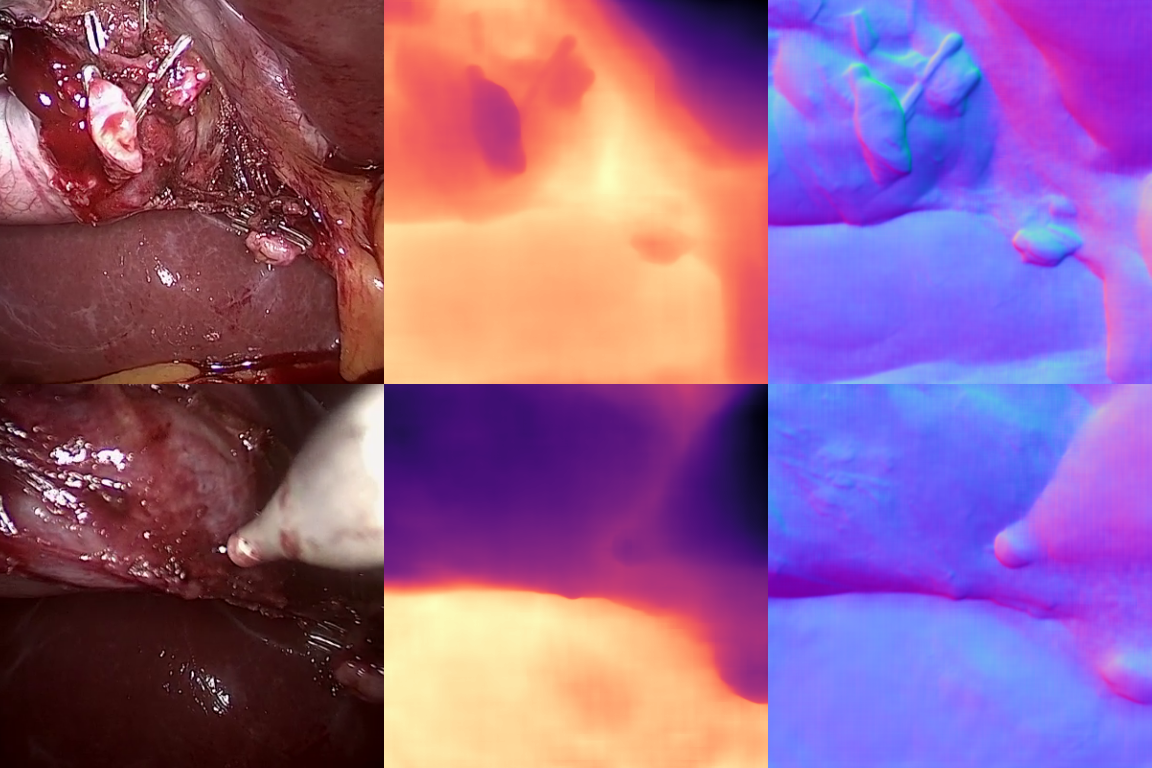

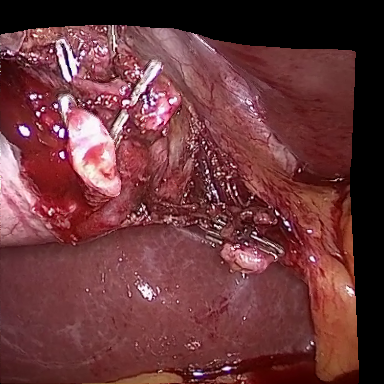

In [ ]:
sample = next(iloader)
framestack = sample["framestack"].to(gpipe.device)
camera_pose_gt = sample["Ts2t"].to(gpipe.device)
depthstack, normals, intrinsics = gpipe.compute_geometry(framestack)
rgb(
    panelize(
    panelize(
        rgb(framestack[:, 0], as_tensor=True),
        rgb(depthstack[:, 0], as_tensor=True),
        rgb(normals[:, 0], as_tensor=True),
    ),
    panelize(
        rgb(framestack[:, 1], as_tensor=True),
        rgb(depthstack[:, 1], as_tensor=True),
        rgb(normals[:, 1], as_tensor=True),
    ),
    mode="vertical",
    )
)


(
    warped,
    source_matched_points,
    target_matched_points_true,
    embedding_mask,
) = mpipe.synthethize_ground_truth(
    framestack, intrinsics[:, 0], camera_pose_gt, depthstack[:, 0]*60+30
).values()
rgb(warped)

In [8]:
depthstack.min(),depthstack.max()

(tensor(0., device='cuda:0'), tensor(1., device='cuda:0'))